# ⚖️ Confronto Locale vs Cluster — Flight Delay 2024

Questo notebook confronta direttamente i risultati ottenuti in **esecuzione locale** 
con quelli ottenuti su **cluster AWS EMR**.

| | Locale | Cluster |
|---|---|---|
| **Hardware** | MacBook (singola macchina) | AWS EMR: 1 master + 3 worker m5.xlarge |
| **CPU totali** | ~8 core | 16 core (4 × 4 vCPU) |
| **RAM totale** | ~8 GB | 64 GB (4 × 16 GB) |
| **Storage** | Locale (SSD) | S3 + HDFS distribuito |
| **Spark master** | `local[*]` | YARN |
| **Shuffle partitions** | 8 | 100 |

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os

PLOTS_DIR = 'plots_local_vs_cluster'
os.makedirs(PLOTS_DIR, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 150, 'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa', 'axes.grid': True, 'grid.alpha': 0.3,
    'font.size': 11, 'axes.titlesize': 14, 'axes.labelsize': 12,
    'legend.fontsize': 10, 'figure.titlesize': 16,
})

COLORS_ENV  = {'local': '#3498db', 'cluster': '#e74c3c'}
COLORS_TECH = {'mapreduce': '#e74c3c', 'hive': '#f39c12', 'spark_core': '#2ecc71', 'spark_sql': '#3498db'}
LABELS_TECH = {'mapreduce': 'MapReduce', 'hive': 'Hive', 'spark_core': 'Spark Core', 'spark_sql': 'Spark SQL'}
MARKERS = {'mapreduce': 's', 'hive': 'D', 'spark_core': '^', 'spark_sql': 'o'}
A_LABELS = {'3.1': '3.1 — Statistiche Compagnie', '3.2': '3.2 — Report Ritardi', '3.3': '3.3 — Ranking Anomalo'}
SAMPLE_ORDER  = ['sample_010pct','sample_025pct','sample_050pct','full_dataset','sample_125pct','sample_150pct']
SAMPLE_LABELS = ['10%','25%','50%','100%','125%','150%']

print('Setup completato ✅')

Setup completato ✅


## 1. Caricamento Dati Locale + Cluster

In [12]:
import os

# Funziona sia se il notebook gira da benchmarks/ che dalla root del progetto
_nb_dir = os.path.dirname(os.path.abspath('confronto_locale_cluster.ipynb'))
_bench_dir = _nb_dir if os.path.exists(os.path.join(_nb_dir, 'results_local.csv')) \
             else os.path.join(os.path.dirname(_nb_dir), 'benchmarks')

def load_results(filename, env_label):
    filepath = os.path.join(_bench_dir, filename)
    df = pd.read_csv(filepath)
    df['analysis']     = df['analysis'].astype(str)
    df['notes']        = df['notes'].fillna('full_dataset')
    df['sample_order'] = df['notes'].map({s: i for i, s in enumerate(SAMPLE_ORDER)})
    df['environment']  = env_label
    return df.sort_values(['analysis', 'technology', 'sample_order'])

local   = load_results('results_local.csv',   'local')
cluster = load_results('results_cluster.csv', 'cluster')
combined = pd.concat([local, cluster], ignore_index=True)

print(f'Locale:  {len(local)} benchmark')
print(f'Cluster: {len(cluster)} benchmark')
print(f'Totale:  {len(combined)} benchmark')

Locale:  54 benchmark
Cluster: 54 benchmark
Totale:  108 benchmark


## 2. Tabella Comparativa — Dataset Completo (100%)

In [13]:
full_local   = local[local['notes']=='full_dataset'][['analysis','technology','elapsed_sec']].rename(columns={'elapsed_sec':'locale_sec'})
full_cluster = cluster[cluster['notes']=='full_dataset'][['analysis','technology','elapsed_sec']].rename(columns={'elapsed_sec':'cluster_sec'})

cmp = full_local.merge(full_cluster, on=['analysis','technology'], how='outer')
cmp['speedup_cluster'] = (cmp['locale_sec'] / cmp['cluster_sec']).round(2)
cmp['analysis_label']  = cmp['analysis'].map(A_LABELS)
cmp['tech_label']      = cmp['technology'].map(LABELS_TECH)
cmp = cmp.sort_values(['analysis','technology'])

display_cols = ['analysis_label','tech_label','locale_sec','cluster_sec','speedup_cluster']
display_df   = cmp[display_cols].copy()
display_df.columns = ['Analisi','Tecnologia','Locale (s)','Cluster (s)','Speedup (locale/cluster)']

def color_speedup(val):
    if pd.isna(val): return ''
    if val >= 2:   return 'background-color: #d4edda; color: #155724; font-weight: bold'
    if val >= 1:   return 'background-color: #fff3cd'
    return 'background-color: #f8d7da'

styled = display_df.style \
    .format({'Locale (s)': '{:.2f}', 'Cluster (s)': '{:.2f}', 'Speedup (locale/cluster)': '{:.2f}×'}) \
    .map(color_speedup, subset=['Speedup (locale/cluster)'])
display(styled)
print('\n🟢 Verde = cluster più veloce (speedup > 2×)  🟡 Giallo = speedup 1-2×  🔴 Rosso = cluster più lento')

,Analisi,Tecnologia,Locale (s),Cluster (s),Speedup (locale/cluster)
0,3.1 — Statistiche Compagnie,Hive,116.17,86.50,1.34×
1,3.1 — Statistiche Compagnie,MapReduce,40.21,55.13,0.73×
2,3.1 — Statistiche Compagnie,Spark SQL,18.78,55.05,0.34×
3,3.2 — Report Ritardi,Hive,231.61,100.65,2.30×
4,3.2 — Report Ritardi,Spark Core,46.73,153.34,0.30×
5,3.2 — Report Ritardi,Spark SQL,10.20,46.48,0.22×
6,3.3 — Ranking Anomalo,MapReduce,50.64,63.58,0.80×
7,3.3 — Ranking Anomalo,Spark Core,33.33,108.41,0.31×
8,3.3 — Ranking Anomalo,Spark SQL,9.29,41.16,0.23×



🟢 Verde = cluster più veloce (speedup > 2×)  🟡 Giallo = speedup 1-2×  🔴 Rosso = cluster più lento


## 3. Bar Chart — Locale vs Cluster per Tecnologia e Analisi

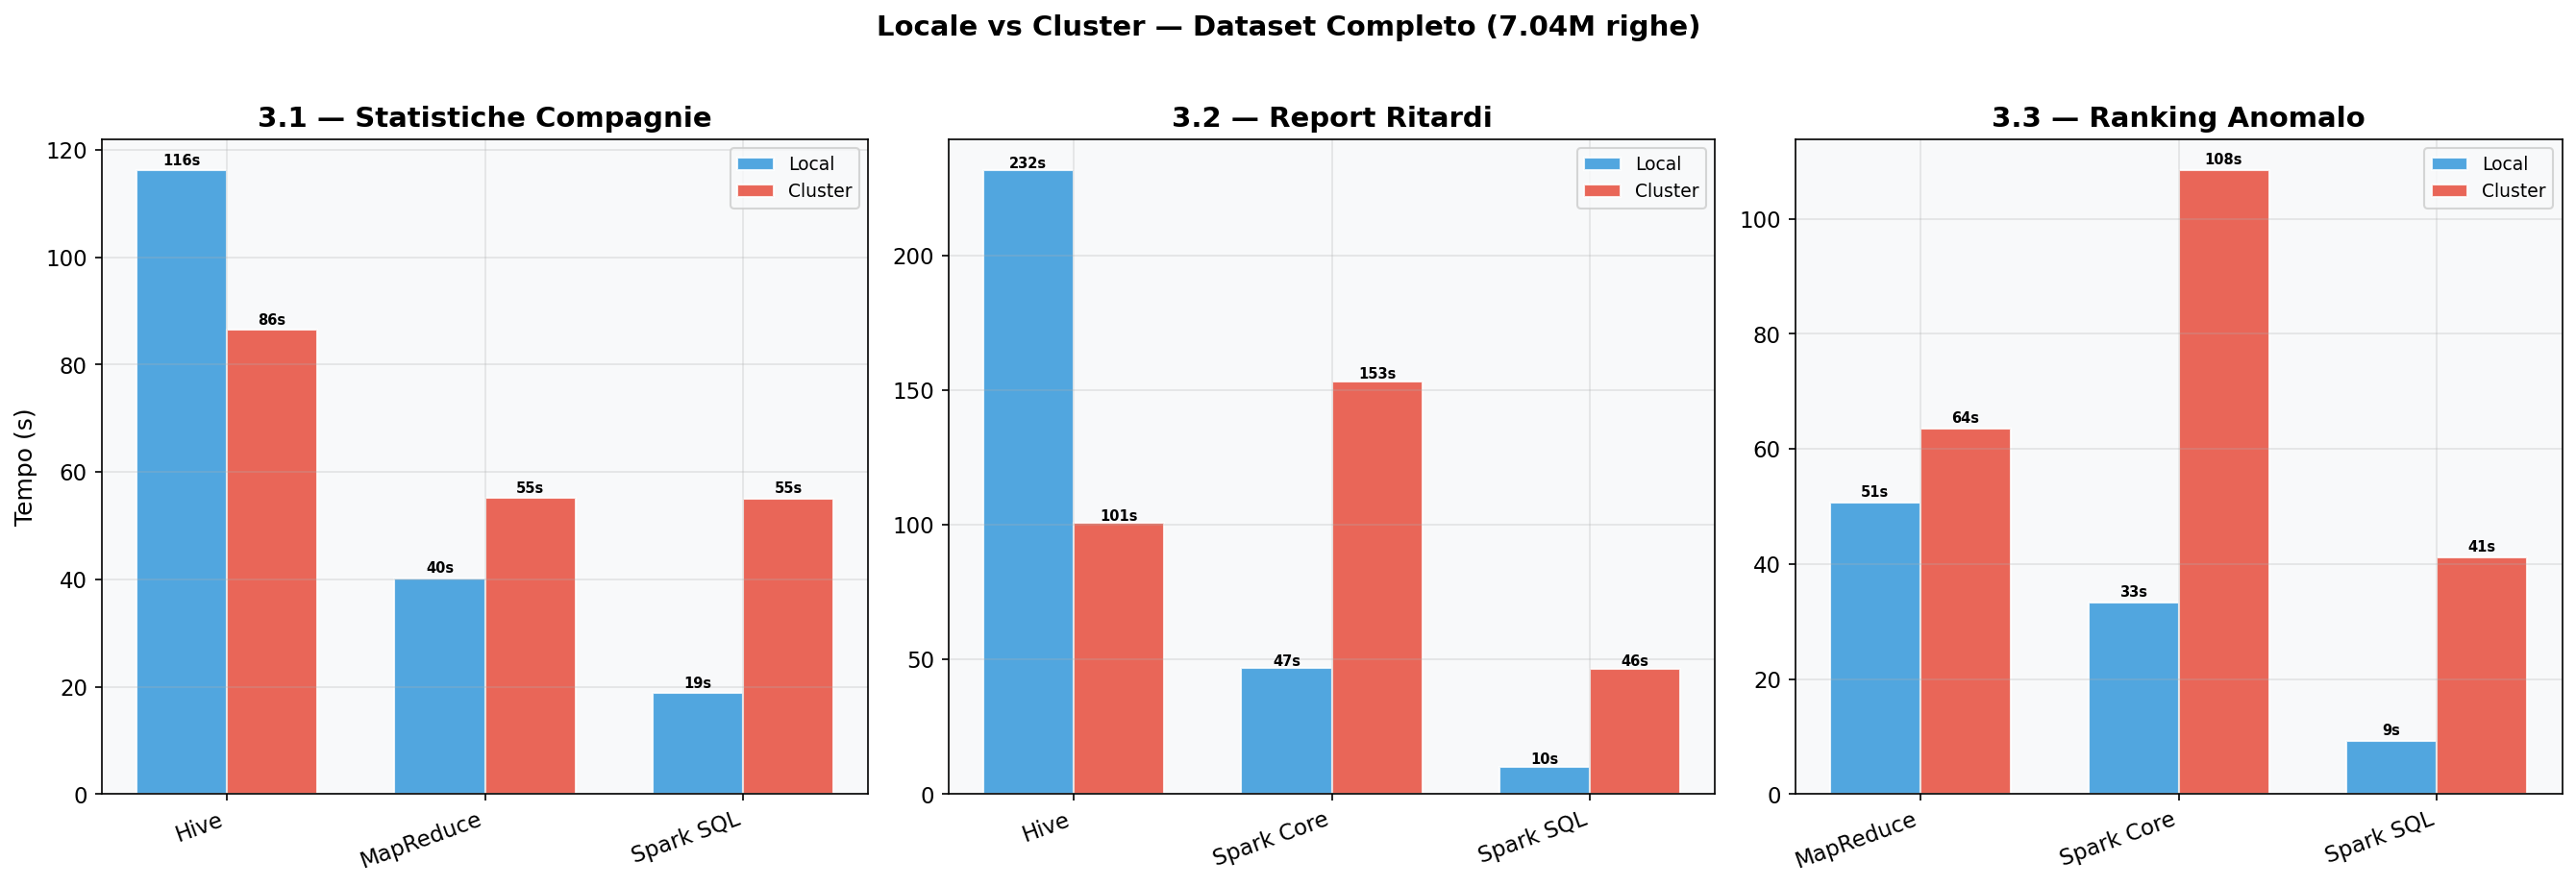

In [14]:
analyses = sorted(combined['analysis'].unique())
fig, axes = plt.subplots(1, len(analyses), figsize=(18, 6), sharey=False)

for ax, analysis in zip(axes, analyses):
    techs = sorted(combined[combined['analysis']==analysis]['technology'].unique())
    x     = np.arange(len(techs))
    w     = 0.35

    for i, env in enumerate(['local','cluster']):
        edf   = combined[(combined['analysis']==analysis) & (combined['notes']=='full_dataset') & (combined['environment']==env)]
        times = [edf[edf['technology']==t]['elapsed_sec'].values[0] if not edf[edf['technology']==t].empty else 0 for t in techs]
        offset = -w/2 if env == 'local' else w/2
        bars = ax.bar(x + offset, times, w, label=env.capitalize(),
                      color=COLORS_ENV[env], alpha=0.85, edgecolor='white')
        for bar, t in zip(bars, times):
            if t > 0:
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                        f'{t:.0f}s', ha='center', fontsize=7, fontweight='bold')

    ax.set_title(A_LABELS.get(analysis, analysis), fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([LABELS_TECH.get(t,t) for t in techs], rotation=20, ha='right')
    ax.set_ylabel('Tempo (s)' if ax==axes[0] else '')
    ax.legend(loc='upper right', fontsize=9)

fig.suptitle('Locale vs Cluster — Dataset Completo (7.04M righe)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/01_locale_vs_cluster_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Speedup Factor — Quante volte il Cluster è più Veloce del Locale

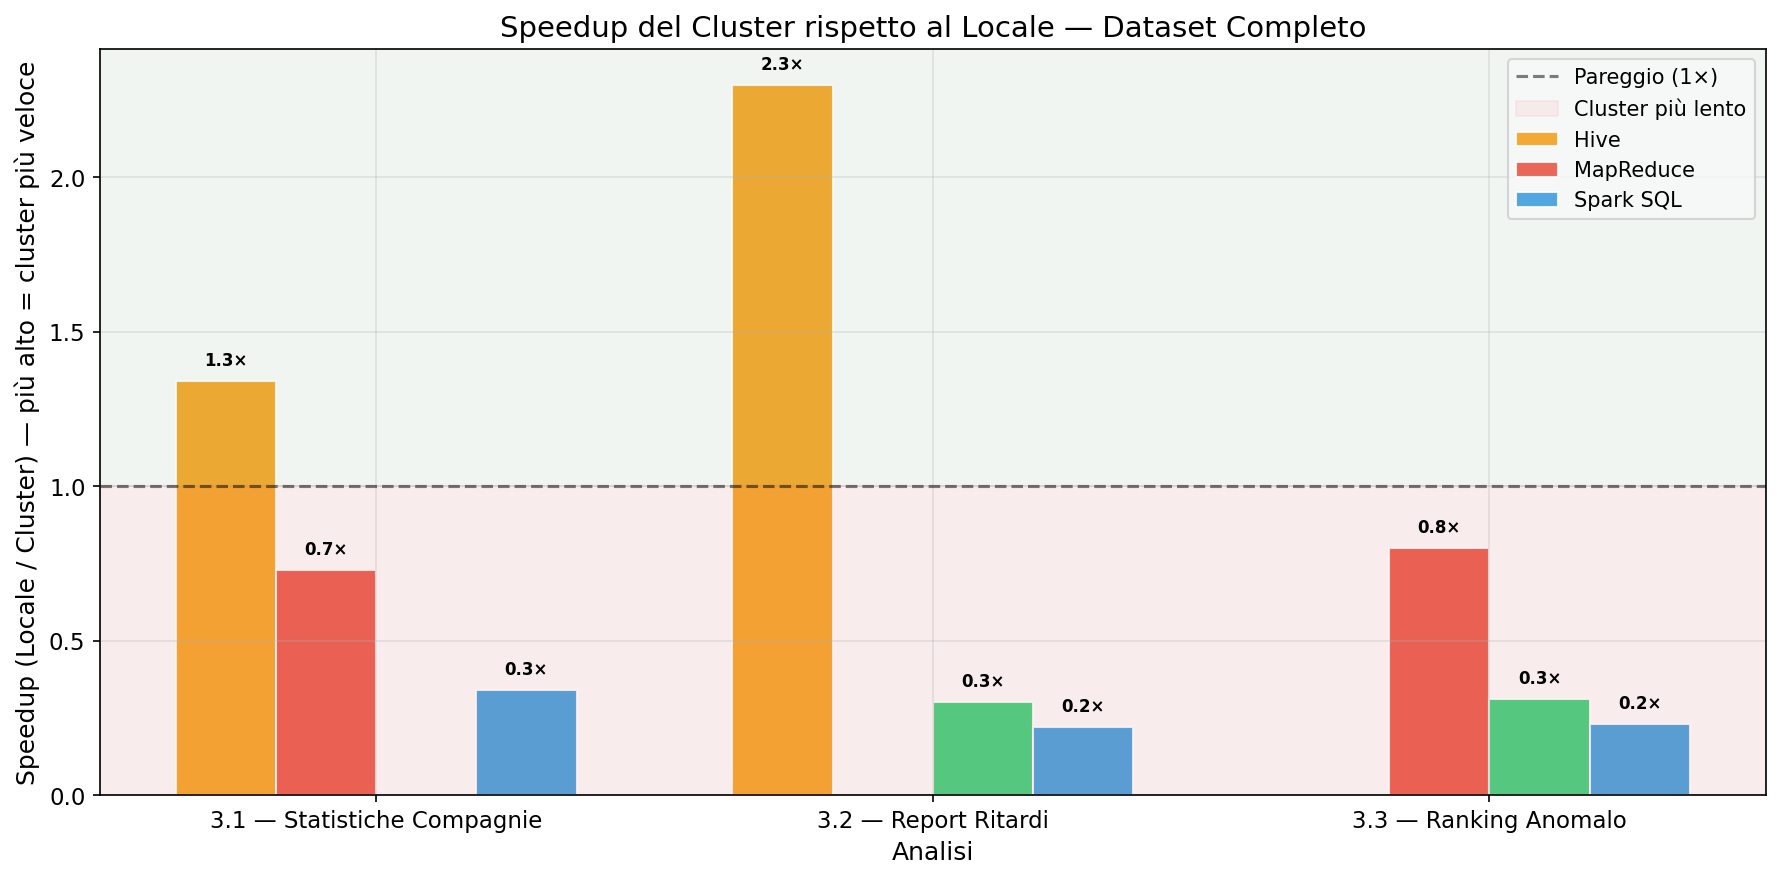


Speedup medio complessivo: 0.73×
Job più veloce su cluster: hive analisi 3.2 (2.3×)
Job più lento su cluster:  spark_sql analisi 3.2 (0.2×)


In [15]:
fig, ax = plt.subplots(figsize=(12, 6))
analyses = sorted(cmp['analysis'].unique())
techs    = sorted(cmp['technology'].unique())
x = np.arange(len(analyses))
width = 0.18
tech_offsets = {t: (i - len(techs)/2 + 0.5) for i, t in enumerate(techs)}

for tech, offset in tech_offsets.items():
    # Allinea i valori all'asse delle analisi, NaN dove la tecnologia non è presente
    speedups = np.array([
        cmp[(cmp['technology']==tech) & (cmp['analysis']==a)]['speedup_cluster'].values[0]
        if not cmp[(cmp['technology']==tech) & (cmp['analysis']==a)].empty else np.nan
        for a in analyses
    ], dtype=float)

    # Disegna solo le barre con valore valido
    for j, (xi, s) in enumerate(zip(x, speedups)):
        if np.isnan(s):
            continue
        bar = ax.bar(xi + offset*width, s, width,
                     label=LABELS_TECH.get(tech,tech) if j == 0 else '_nolegend_',
                     color=COLORS_TECH.get(tech,'#999'), edgecolor='white', alpha=0.85)
        ax.text(xi + offset*width, s + 0.05, f'{s:.1f}×',
                ha='center', fontsize=8, fontweight='bold')

ax.axhline(y=1, color='black', linestyle='--', alpha=0.5, linewidth=1.5, label='Pareggio (1×)')
ymax = max(ax.get_ylim()[1], 1.5)
ax.set_ylim(0, ymax)
ax.axhspan(0, 1, alpha=0.05, color='red', label='Cluster più lento')
ax.axhspan(1, ymax, alpha=0.03, color='green')
ax.set_xlabel('Analisi')
ax.set_ylabel('Speedup (Locale / Cluster) — più alto = cluster più veloce')
ax.set_title('Speedup del Cluster rispetto al Locale — Dataset Completo')
ax.set_xticks(x)
ax.set_xticklabels([A_LABELS.get(a,a) for a in analyses])
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/02_speedup_cluster_vs_locale.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nSpeedup medio complessivo: {cmp["speedup_cluster"].mean():.2f}×')
best  = cmp.loc[cmp["speedup_cluster"].idxmax()]
worst = cmp.loc[cmp["speedup_cluster"].idxmin()]
print(f'Job più veloce su cluster: {best["technology"]} analisi {best["analysis"]} ({best["speedup_cluster"]:.1f}×)')
print(f'Job più lento su cluster:  {worst["technology"]} analisi {worst["analysis"]} ({worst["speedup_cluster"]:.1f}×)')

## 5. Scalabilità Sovrapposta — Locale (tratteggiato) vs Cluster (pieno)

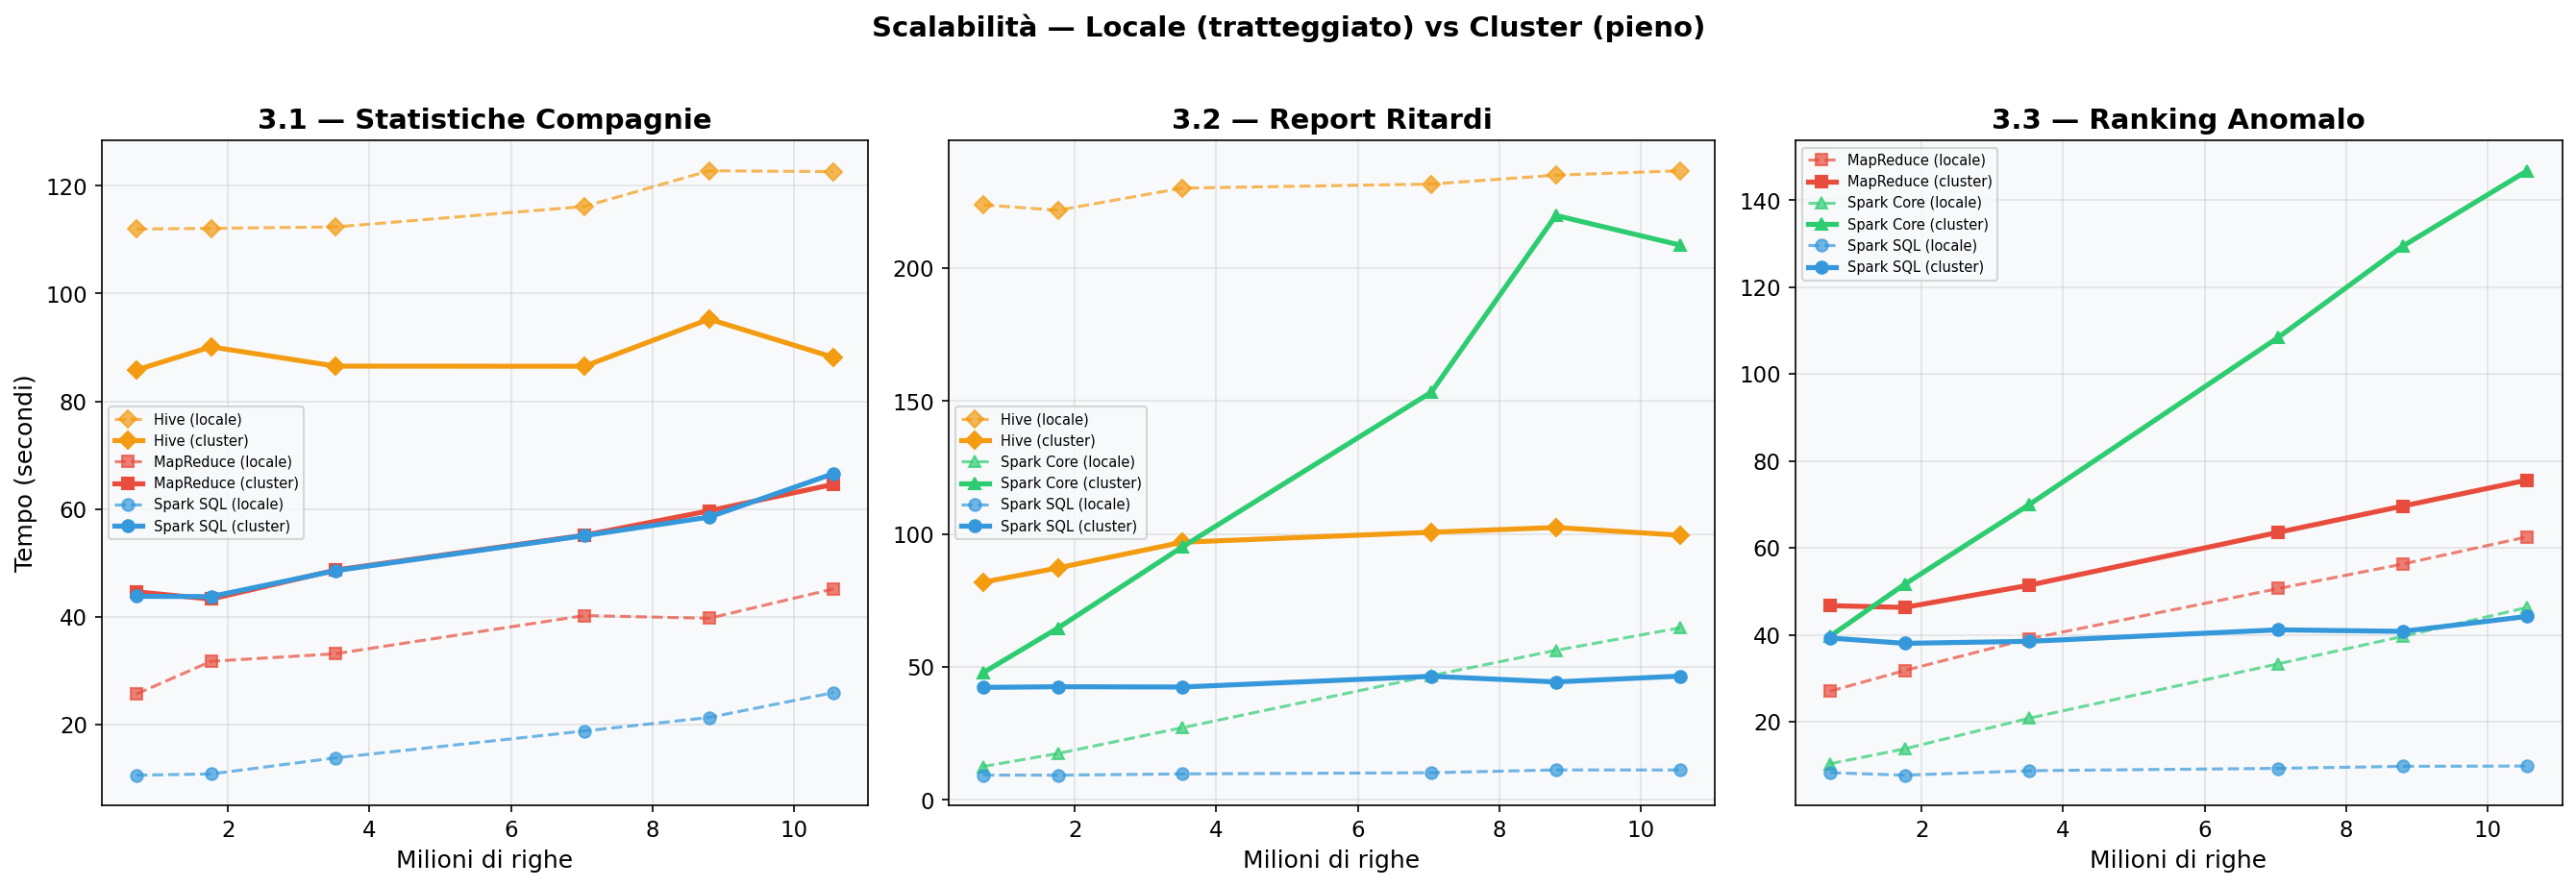

In [16]:
analyses = sorted(combined['analysis'].unique())
fig, axes = plt.subplots(1, len(analyses), figsize=(18, 6), sharey=False)

for ax, analysis in zip(axes, analyses):
    techs = sorted(combined[combined['analysis']==analysis]['technology'].unique())
    for tech in techs:
        color = COLORS_TECH.get(tech, '#666')
        marker = MARKERS.get(tech, 'o')
        for env, ls, lw, alpha in [('local','--',1.5,0.7), ('cluster','-',2.5,1.0)]:
            tdf = combined[(combined['analysis']==analysis) &
                           (combined['technology']==tech) &
                           (combined['environment']==env)].sort_values('sample_order')
            if tdf.empty: continue
            label = f"{LABELS_TECH.get(tech,tech)} ({'locale' if env=='local' else 'cluster'})"
            ax.plot(tdf['input_rows']/1e6, tdf['elapsed_sec'],
                    linestyle=ls, linewidth=lw, marker=marker, markersize=6,
                    color=color, alpha=alpha, label=label)

    ax.set_title(A_LABELS.get(analysis, analysis), fontweight='bold')
    ax.set_xlabel('Milioni di righe')
    if ax == axes[0]: ax.set_ylabel('Tempo (secondi)')
    ax.legend(fontsize=7, ncol=1)

fig.suptitle('Scalabilità — Locale (tratteggiato) vs Cluster (pieno)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/03_scalabilita_locale_vs_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Heatmap Speedup — Cluster / Locale (per ogni combinazione analisi × tecnologia)

/var/folders/k0/__zyx3fx31ngwx2_l25yzwdc0000gn/T/ipykernel_49245/102306047.py:26: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k0/__zyx3fx31ngwx2_l25yzwdc0000gn/T/ipykernel_49245/102306047.py:26: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k0/__zyx3fx31ngwx2_l25yzwdc0000gn/T/ipykernel_49245/102306047.py:27: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{PLOTS_DIR}/04_heatmap_speedup.png', dpi=150, bbox_inches='tight')
/var/folders/k0/__zyx3fx31ngwx2_l25yzwdc0000gn/T/ipykernel_49245/102306047.py:27: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{PLOTS_DIR}/04_heatmap_speedup.png', dpi=150, bbox_inches='tight')
/Users/diego/Desktop/Hadoop-Hive-Spark-FlightsDelay/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarni

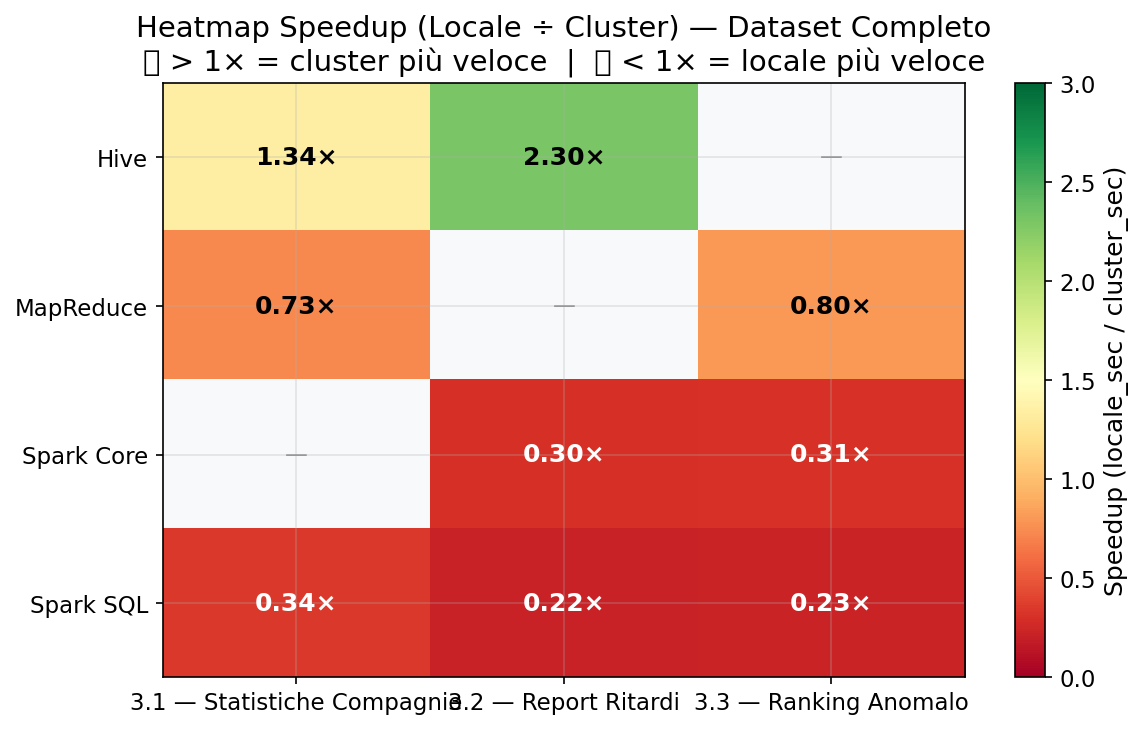

In [17]:
analyses = sorted(cmp['analysis'].unique())
techs    = sorted(cmp['technology'].unique())
matrix   = np.array([[cmp[(cmp['analysis']==a)&(cmp['technology']==t)]['speedup_cluster'].values[0]
                       if not cmp[(cmp['analysis']==a)&(cmp['technology']==t)].empty else np.nan
                       for a in analyses] for t in techs])

fig, ax = plt.subplots(figsize=(8, 5))
# Colormap centrata su 1 (bianco = pareggio, verde = cluster vince, rosso = locale vince)
vmin, vmax = 0, max(3, np.nanmax(matrix))
im = ax.imshow(matrix, cmap='RdYlGn', aspect='auto', vmin=vmin, vmax=vmax)
ax.set_xticks(range(len(analyses))); ax.set_xticklabels([A_LABELS.get(a,a) for a in analyses])
ax.set_yticks(range(len(techs)));    ax.set_yticklabels([LABELS_TECH.get(t,t) for t in techs])
for i in range(len(techs)):
    for j in range(len(analyses)):
        val = matrix[i,j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.2f}×', ha='center', va='center',
                    fontweight='bold', fontsize=12,
                    color='black' if 0.6 < val < 2.5 else 'white')
        else:
            ax.text(j, i, '—', ha='center', va='center', fontsize=11, color='#999')
ax.set_title('Heatmap Speedup (Locale ÷ Cluster) — Dataset Completo\n'
             '🟢 > 1× = cluster più veloce  |  🔴 < 1× = locale più veloce')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Speedup (locale_sec / cluster_sec)')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/04_heatmap_speedup.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Throughput Comparativo — K righe/secondo

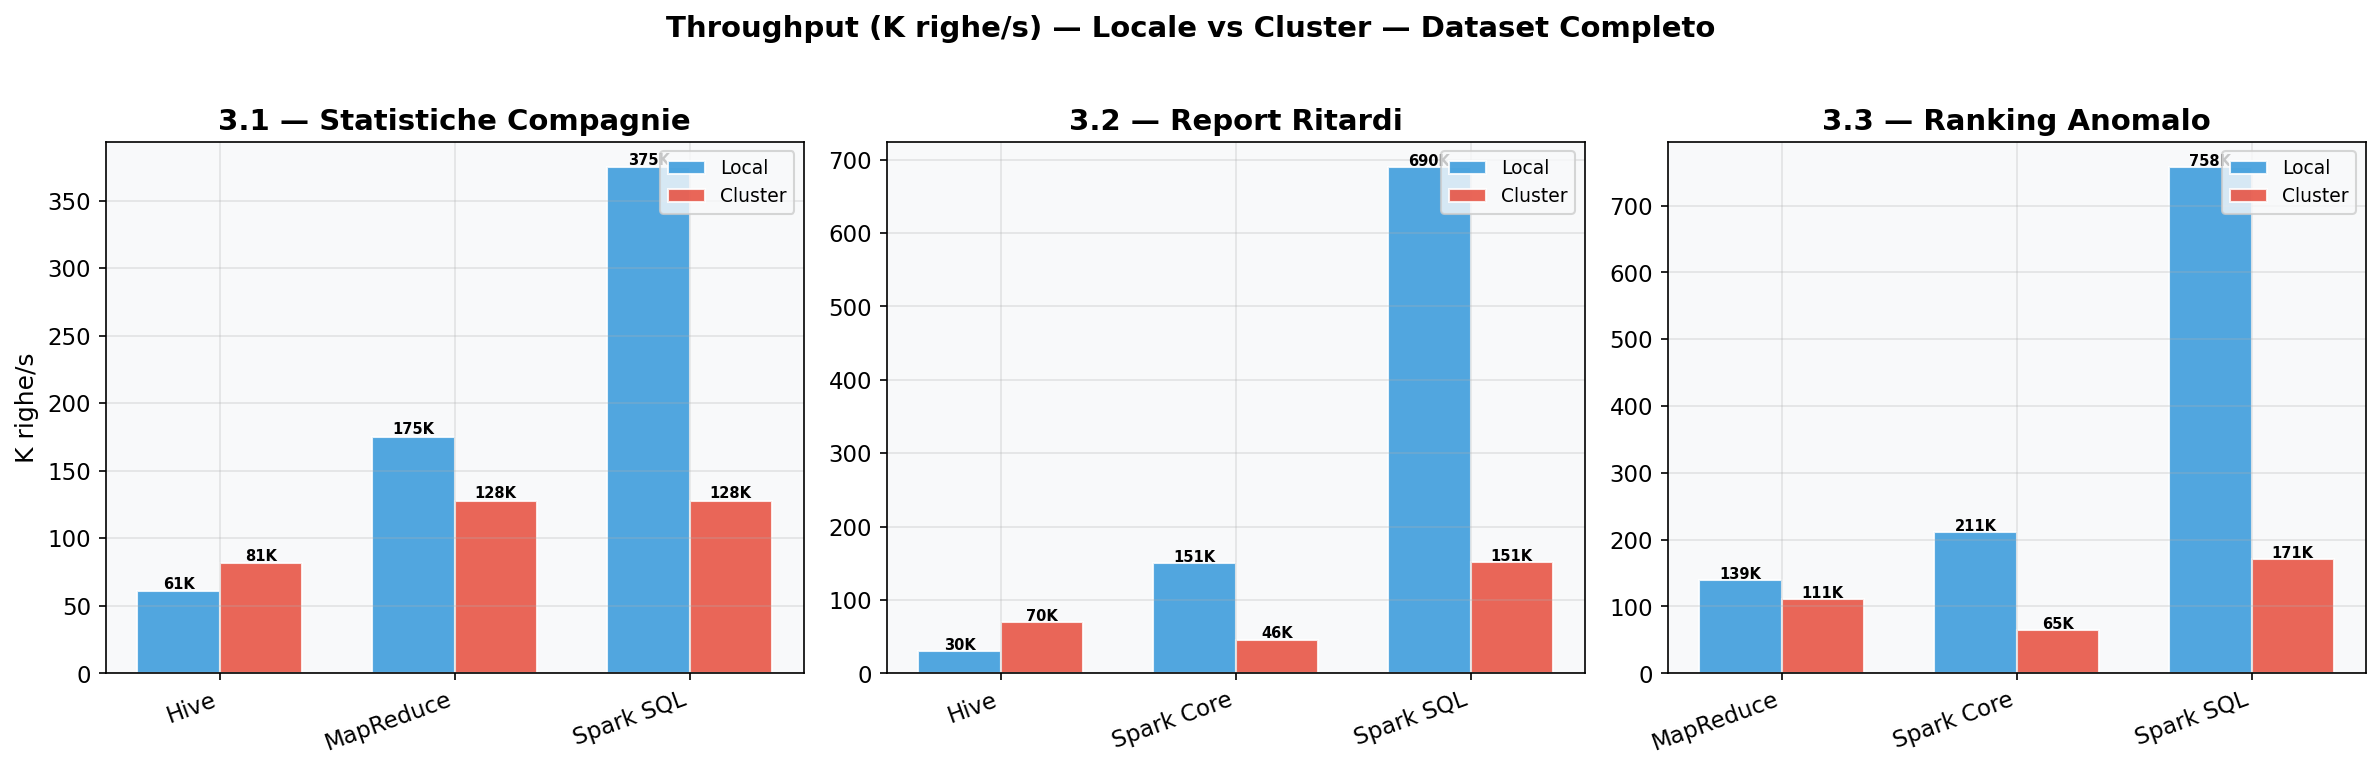

In [18]:
full_combined = combined[combined['notes']=='full_dataset'].copy()
full_combined['throughput_k'] = full_combined['input_rows'] / full_combined['elapsed_sec'] / 1000

analyses = sorted(full_combined['analysis'].unique())
fig, axes = plt.subplots(1, len(analyses), figsize=(16, 5), sharey=False)

for ax, analysis in zip(axes, analyses):
    techs = sorted(full_combined[full_combined['analysis']==analysis]['technology'].unique())
    x = np.arange(len(techs))
    w = 0.35
    for i, env in enumerate(['local','cluster']):
        edf = full_combined[(full_combined['analysis']==analysis) & (full_combined['environment']==env)]
        tp  = [edf[edf['technology']==t]['throughput_k'].values[0]
               if not edf[edf['technology']==t].empty else 0 for t in techs]
        offset = -w/2 if env == 'local' else w/2
        bars = ax.bar(x + offset, tp, w, label=env.capitalize(),
                      color=COLORS_ENV[env], alpha=0.85, edgecolor='white')
        for bar, t in zip(bars, tp):
            if t > 0:
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                        f'{t:.0f}K', ha='center', fontsize=7, fontweight='bold')
    ax.set_title(A_LABELS.get(analysis, analysis), fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([LABELS_TECH.get(t,t) for t in techs], rotation=20, ha='right')
    ax.set_ylabel('K righe/s' if ax==axes[0] else '')
    ax.legend(loc='upper right', fontsize=9)

fig.suptitle('Throughput (K righe/s) — Locale vs Cluster — Dataset Completo',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/05_throughput_confronto.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Riepilogo Testuale — Considerazioni Finali

In [19]:
print('=' * 65)
print('  RIEPILOGO CONFRONTO LOCALE vs CLUSTER — DATASET COMPLETO')
print('=' * 65)

for _, row in cmp.sort_values(['analysis','technology']).iterrows():
    tech  = LABELS_TECH.get(row['technology'], row['technology'])
    ana   = row['analysis']
    loc   = row['locale_sec']
    clu   = row['cluster_sec']
    sp    = row['speedup_cluster']
    if pd.isna(sp):
        note = '(dato mancante)'
    elif sp >= 2:
        note = f'✅ Cluster {sp:.1f}× più veloce'
    elif sp >= 1:
        note = f'🟡 Cluster leggermente più veloce ({sp:.1f}×)'
    else:
        note = f'⚠️  Locale più veloce (cluster {1/sp:.1f}× più lento)'
    print(f'  Analisi {ana} | {tech:<12} | Locale: {loc:>6.1f}s | Cluster: {clu:>6.1f}s | {note}')

print()
print(f'  Speedup medio: {cmp["speedup_cluster"].mean():.2f}×')
print(f'  Job con massimo speedup: {cmp.loc[cmp["speedup_cluster"].idxmax(), "technology"]} '
      f'analisi {cmp.loc[cmp["speedup_cluster"].idxmax(), "analysis"]} '
      f'({cmp["speedup_cluster"].max():.1f}×)')
print('=' * 65)

  RIEPILOGO CONFRONTO LOCALE vs CLUSTER — DATASET COMPLETO
  Analisi 3.1 | Hive         | Locale:  116.2s | Cluster:   86.5s | 🟡 Cluster leggermente più veloce (1.3×)
  Analisi 3.1 | MapReduce    | Locale:   40.2s | Cluster:   55.1s | ⚠️  Locale più veloce (cluster 1.4× più lento)
  Analisi 3.1 | Spark SQL    | Locale:   18.8s | Cluster:   55.0s | ⚠️  Locale più veloce (cluster 2.9× più lento)
  Analisi 3.2 | Hive         | Locale:  231.6s | Cluster:  100.7s | ✅ Cluster 2.3× più veloce
  Analisi 3.2 | Spark Core   | Locale:   46.7s | Cluster:  153.3s | ⚠️  Locale più veloce (cluster 3.3× più lento)
  Analisi 3.2 | Spark SQL    | Locale:   10.2s | Cluster:   46.5s | ⚠️  Locale più veloce (cluster 4.5× più lento)
  Analisi 3.3 | MapReduce    | Locale:   50.6s | Cluster:   63.6s | ⚠️  Locale più veloce (cluster 1.2× più lento)
  Analisi 3.3 | Spark Core   | Locale:   33.3s | Cluster:  108.4s | ⚠️  Locale più veloce (cluster 3.2× più lento)
  Analisi 3.3 | Spark SQL    | Locale:    9.3s | 

In [20]:
print(f'\n✅ Tutti i grafici di confronto salvati in: {PLOTS_DIR}/')
print(f'   Grafici generati: {len(os.listdir(PLOTS_DIR))}')


✅ Tutti i grafici di confronto salvati in: plots_local_vs_cluster/
   Grafici generati: 5
